In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import re
import warnings
import matplotlib.pyplot as plt #visualization
import seaborn as sns #For statistical graphics
import librosa #for handling music and audio files
import librosa.display #waveforms and spectograms
from sklearn.preprocessing import minmax_scale #normalization
import IPython.display as ipd #playing audio files in jupyter notebook

In [ ]:
import os
import pandas as pd

# Define the dataset directory
directory = "training\data set"

# Initialize a list to store file information
data_list = []

# Traverse through the directory and subdirectories
for root, _, files in os.walk(directory):
    for file in files:
        # Get the full file path
        filepath = os.path.join(root, file)
        
        # Extract the label from the subdirectory name (assuming subdirectory = label)
        label = os.path.basename(root)
        
        # Append file path and label to the list
        data_list.append({'filename': filepath, 'label': label})

# Convert the list to a pandas DataFrame
data = pd.DataFrame(data_list)

# Display the DataFrame
print(data)

# Save to CSV for reuse (optional)
data.to_csv("Training data set", index=False)

                                               filename                 label
0     C:\Users\Fizza\Documents\Model CNN1\training\d...  wav_arrayMic_FC01S01
1     C:\Users\Fizza\Documents\Model CNN1\training\d...  wav_arrayMic_FC01S01
2     C:\Users\Fizza\Documents\Model CNN1\training\d...  wav_arrayMic_FC01S01
3     C:\Users\Fizza\Documents\Model CNN1\training\d...  wav_arrayMic_FC01S01
4     C:\Users\Fizza\Documents\Model CNN1\training\d...  wav_arrayMic_FC01S01
...                                                 ...                   ...
4510  C:\Users\Fizza\Documents\Model CNN1\training\d...    wav_headMic_M01S02
4511  C:\Users\Fizza\Documents\Model CNN1\training\d...    wav_headMic_M01S02
4512  C:\Users\Fizza\Documents\Model CNN1\training\d...    wav_headMic_M01S02
4513  C:\Users\Fizza\Documents\Model CNN1\training\d...    wav_headMic_M01S02
4514  C:\Users\Fizza\Documents\Model CNN1\training\d...    wav_headMic_M01S02

[4515 rows x 2 columns]


In [ ]:
#Data Visualization
directory = r'trainingdata set'
data = pd.read_csv("training data set")
data

,filename,label
0,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_arrayMic_FC01S01
1,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_arrayMic_FC01S01
2,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_arrayMic_FC01S01
3,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_arrayMic_FC01S01
4,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_arrayMic_FC01S01
...,...,...
4510,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_headMic_M01S02
4511,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_headMic_M01S02
4512,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_headMic_M01S02
4513,C:\Users\Fizza\Documents\Model CNN1\training\d...,wav_headMic_M01S02


In [ ]:
import pandas as pd

F_Con = pd.read_csv(r'training data set')
F_Dys = pd.read_csv(r'training data set')
M_Con = pd.read_csv(r'training data set')
M_Dys = pd.read_csv(r'training data set')

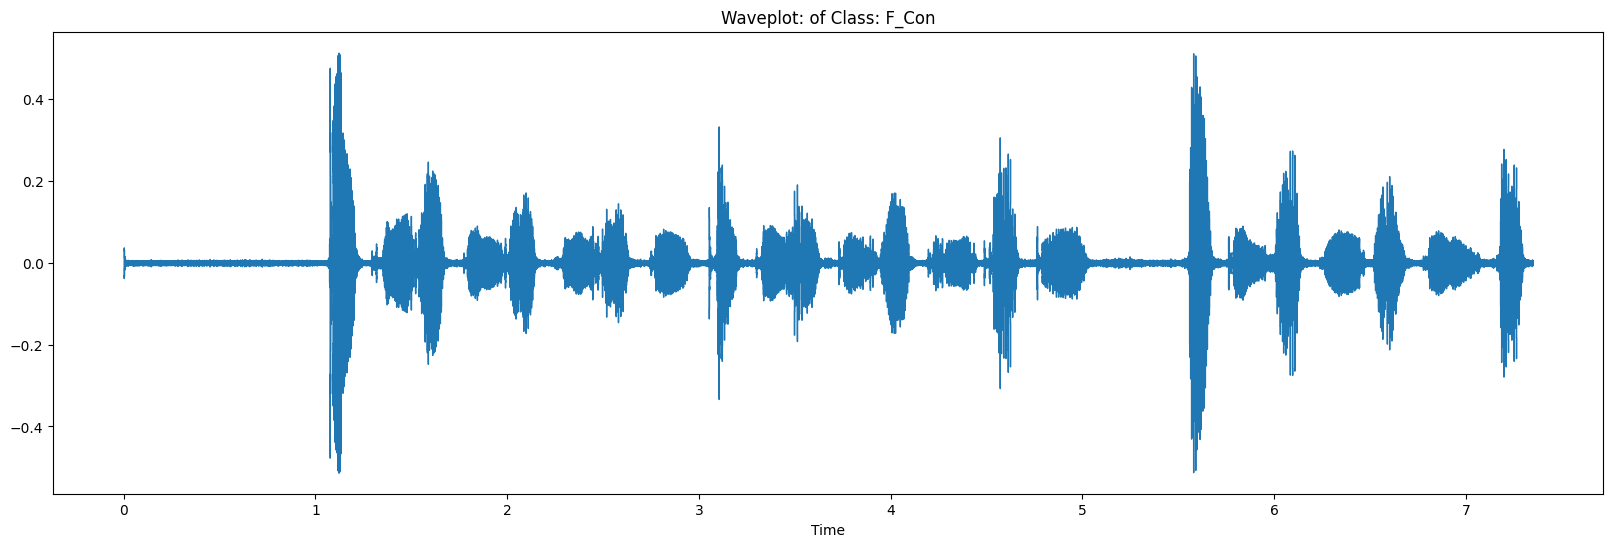

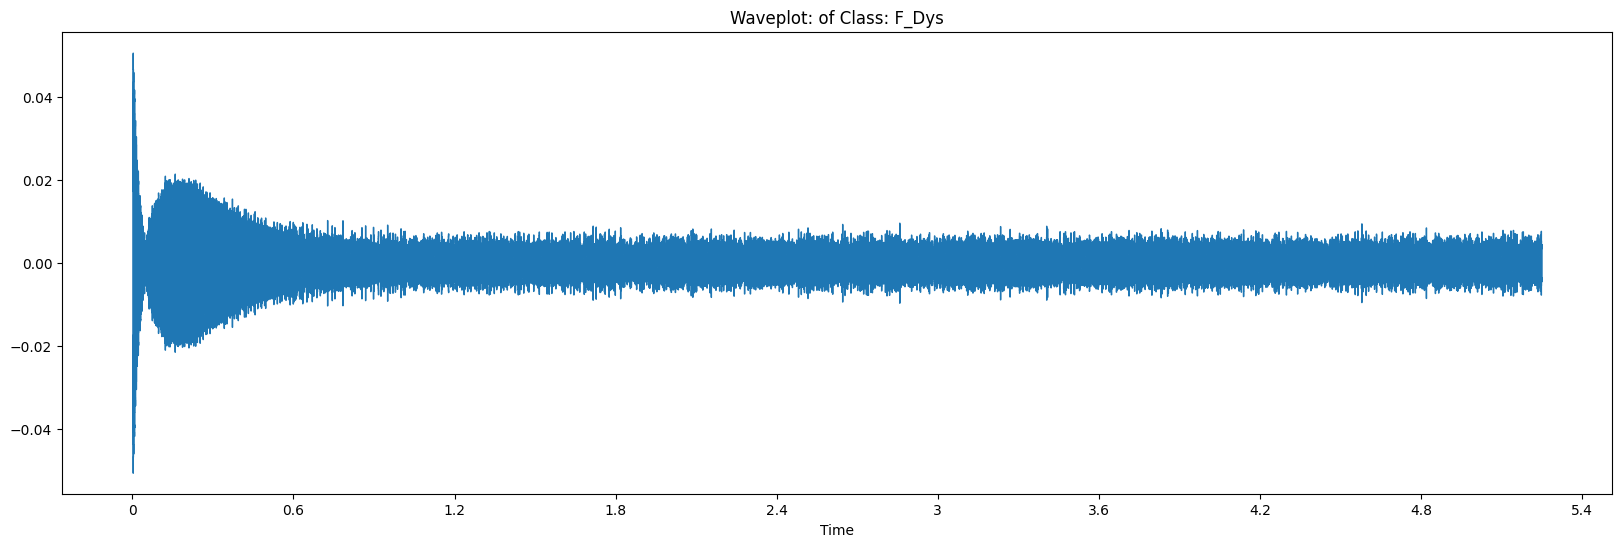

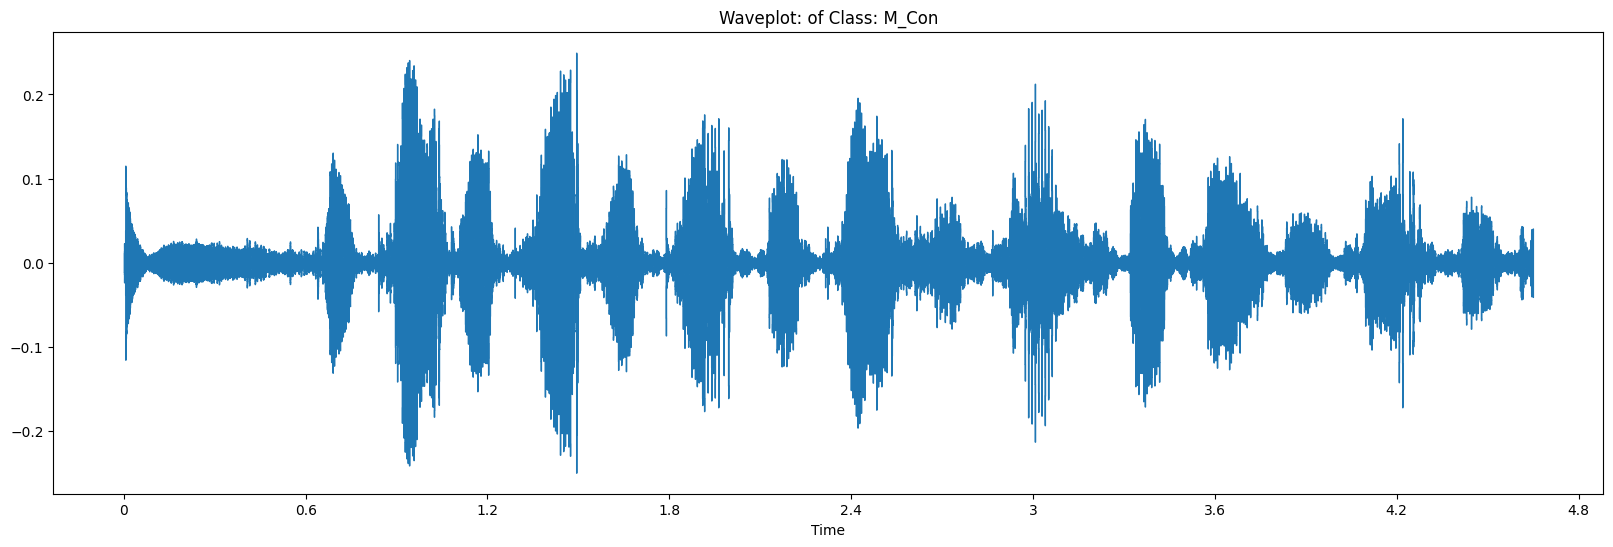

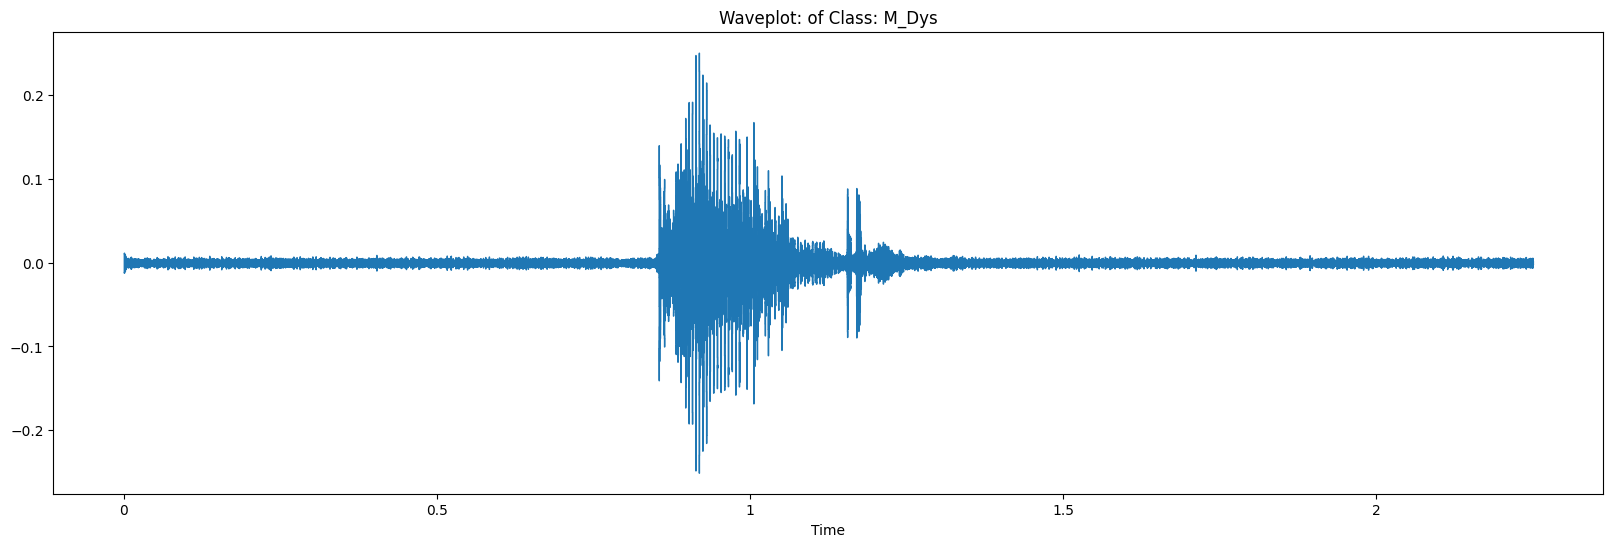

In [6]:
#Visualization: Feature(waveplot) waveplot 
def show_waveplot(filename,label):#filename as audio path
    x , sr = librosa.load(filename)
    plt.figure(figsize=(20, 6))
    librosa.display.waveshow(x, sr=sr)
    plt.title(f"Waveplot: of Class: {label}")

show_waveplot(F_Con.iloc[1].filename, "F_Con")
show_waveplot(F_Dys.iloc[2].filename, "F_Dys")
show_waveplot(M_Con.iloc[3].filename, "M_Con")
show_waveplot(M_Dys.iloc[4].filename, "M_Dys")

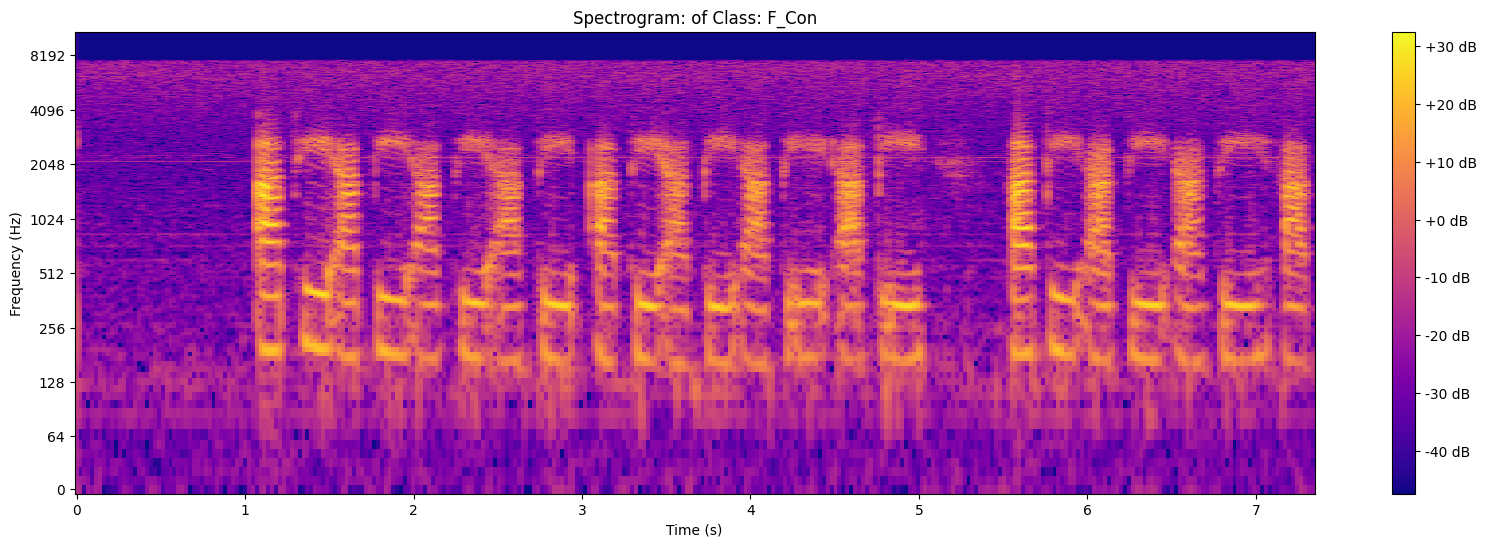

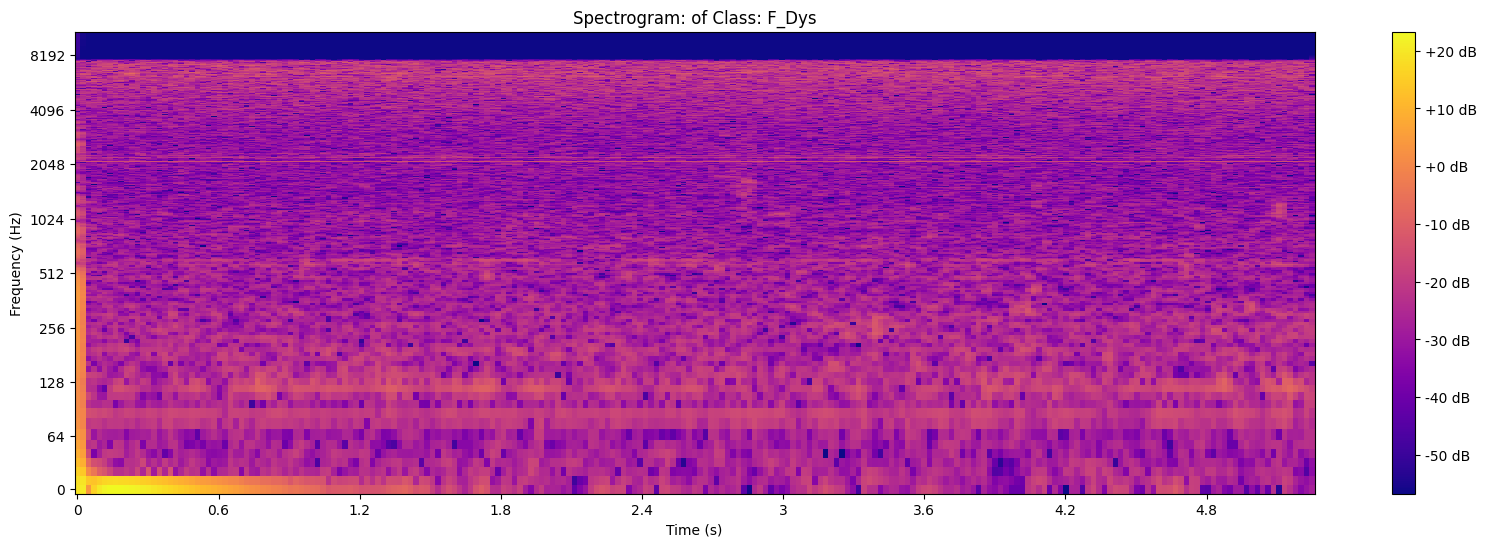

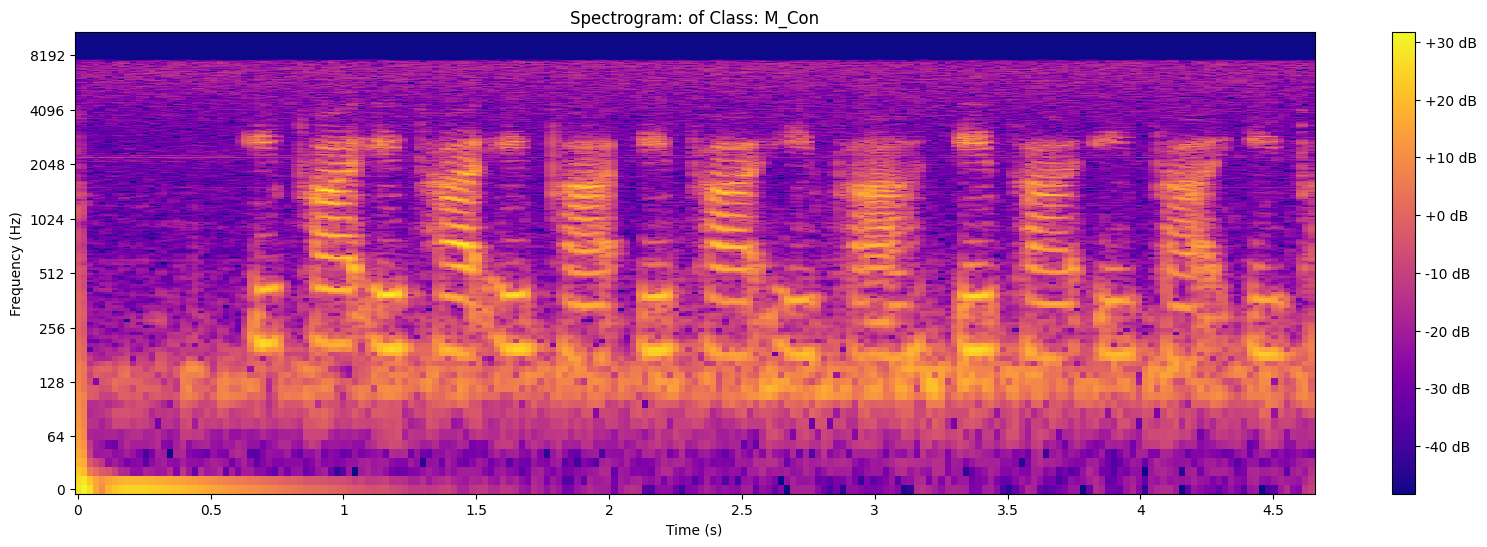

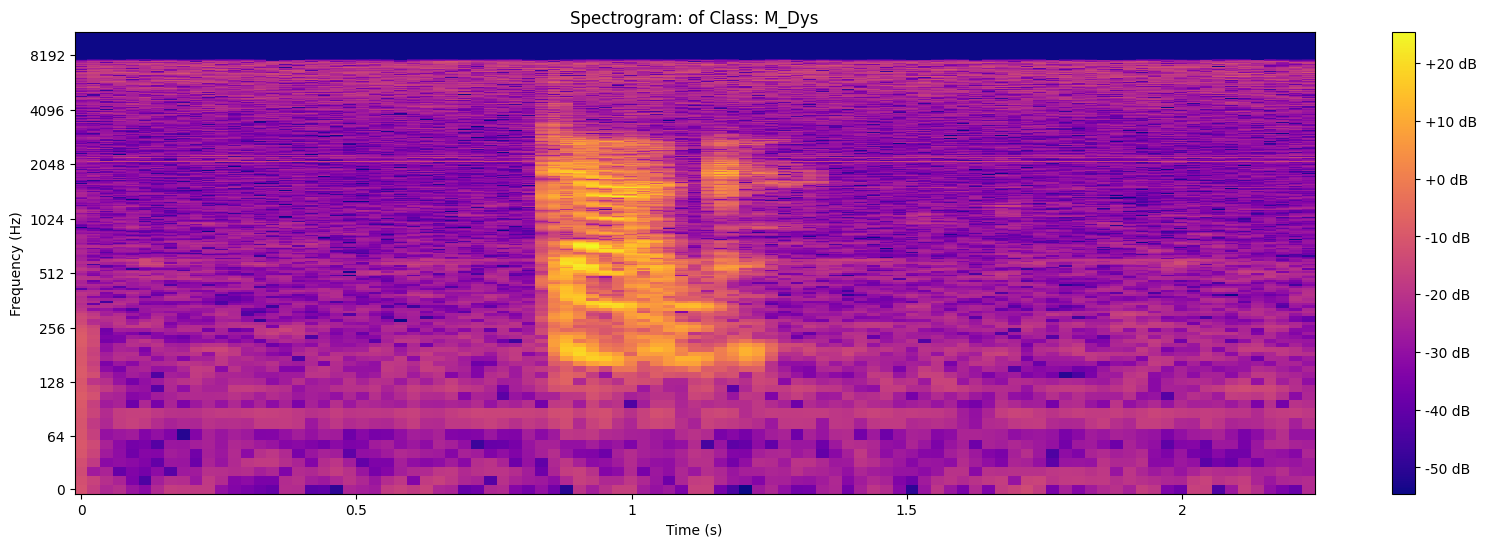

In [7]:
# Function to display a spectrogram
def show_spectrogram(filename, label):  # filename as audio path
    try:
        # Load the audio file
        x, sr = librosa.load(filename)
        
        # Compute the Short-Time Fourier Transform (STFT) to create a spectrogram
        S = librosa.stft(x)
        S_db = librosa.amplitude_to_db(abs(S))  # Convert amplitude to decibels
        
        # Plot the spectrogram
        plt.figure(figsize=(20, 6))
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='plasma')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Spectrogram: of Class: {label}")
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.show()
    except Exception as e:
        print(f"Error loading {filename}: {e}")

# Example usage (replace with your actual DataFrame and column names)
show_spectrogram(F_Con.iloc[1].filename, "F_Con")
show_spectrogram(F_Dys.iloc[2].filename, "F_Dys")
show_spectrogram(M_Con.iloc[3].filename, "M_Con")
show_spectrogram(M_Dys.iloc[4].filename, "M_Dys")

Sum of zero crossings: 38473


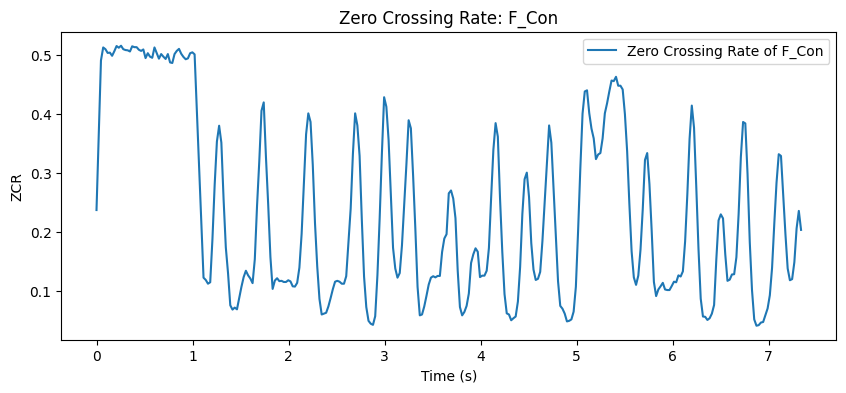

Sum of zero crossings: 51845


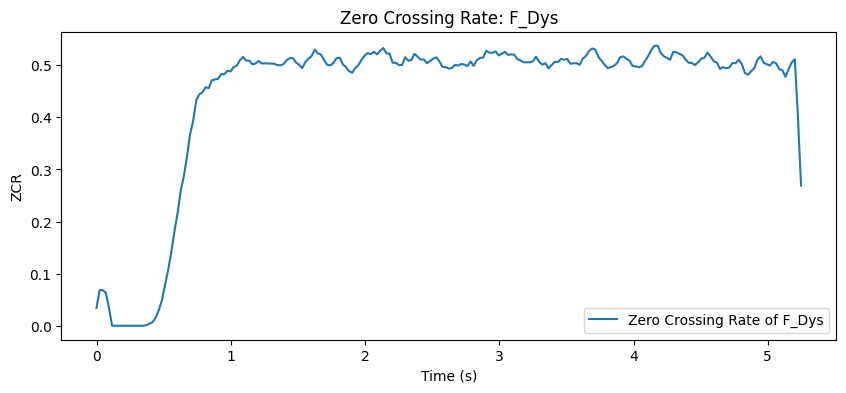

Sum of zero crossings: 10960


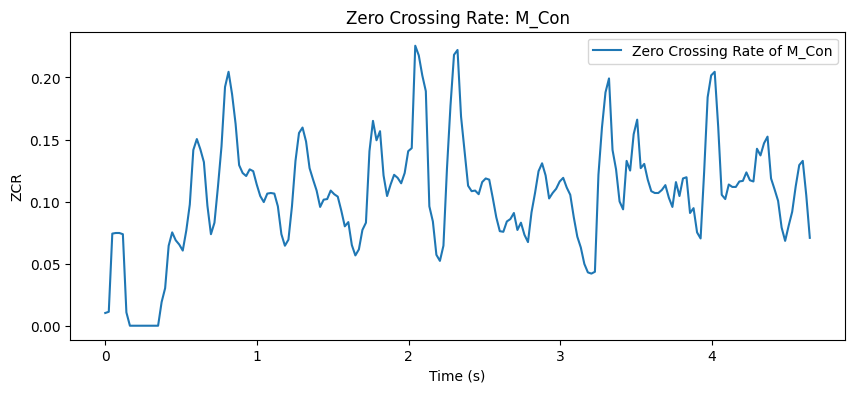

Sum of zero crossings: 21706


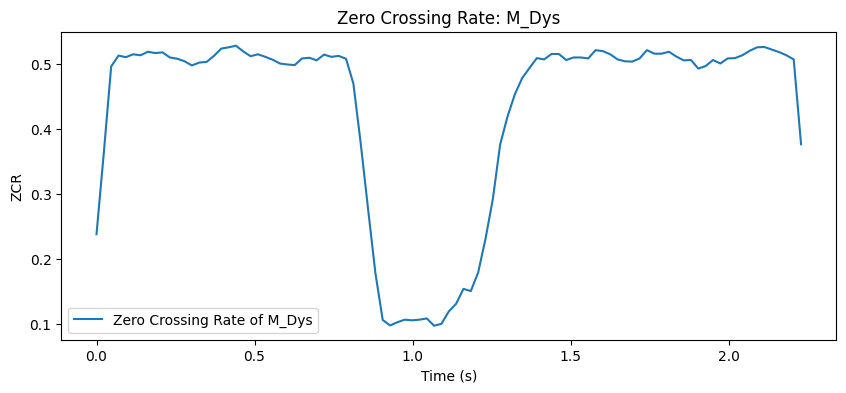

In [8]:
# Function to calculate and plot Zero Crossing Rate
def plot_zero_crossing_rate(filename, label):
    # Load the audio file
    x, sr = librosa.load(filename)

     # Calculate total zero crossings
    zero_crossings = librosa.zero_crossings(x)
    print(f"Sum of zero crossings: {zero_crossings.sum()}")
    
    # Calculate Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(x)[0]
    
    # Create time axis in seconds
    frames = range(len(zcr))
    t = librosa.frames_to_time(frames, sr=sr)
    
    # Plot the ZCR
    plt.figure(figsize=(10, 4))
    plt.plot(t, zcr, label=f"Zero Crossing Rate of {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("ZCR")
    plt.title(f"Zero Crossing Rate: {label}")
    plt.legend()
    plt.show()

# Example usage with your audio files
plot_zero_crossing_rate(F_Con.iloc[1].filename, "F_Con")
plot_zero_crossing_rate(F_Dys.iloc[2].filename, "F_Dys")
plot_zero_crossing_rate(M_Con.iloc[3].filename, "M_Con")
plot_zero_crossing_rate(M_Dys.iloc[4].filename, "M_Dys")

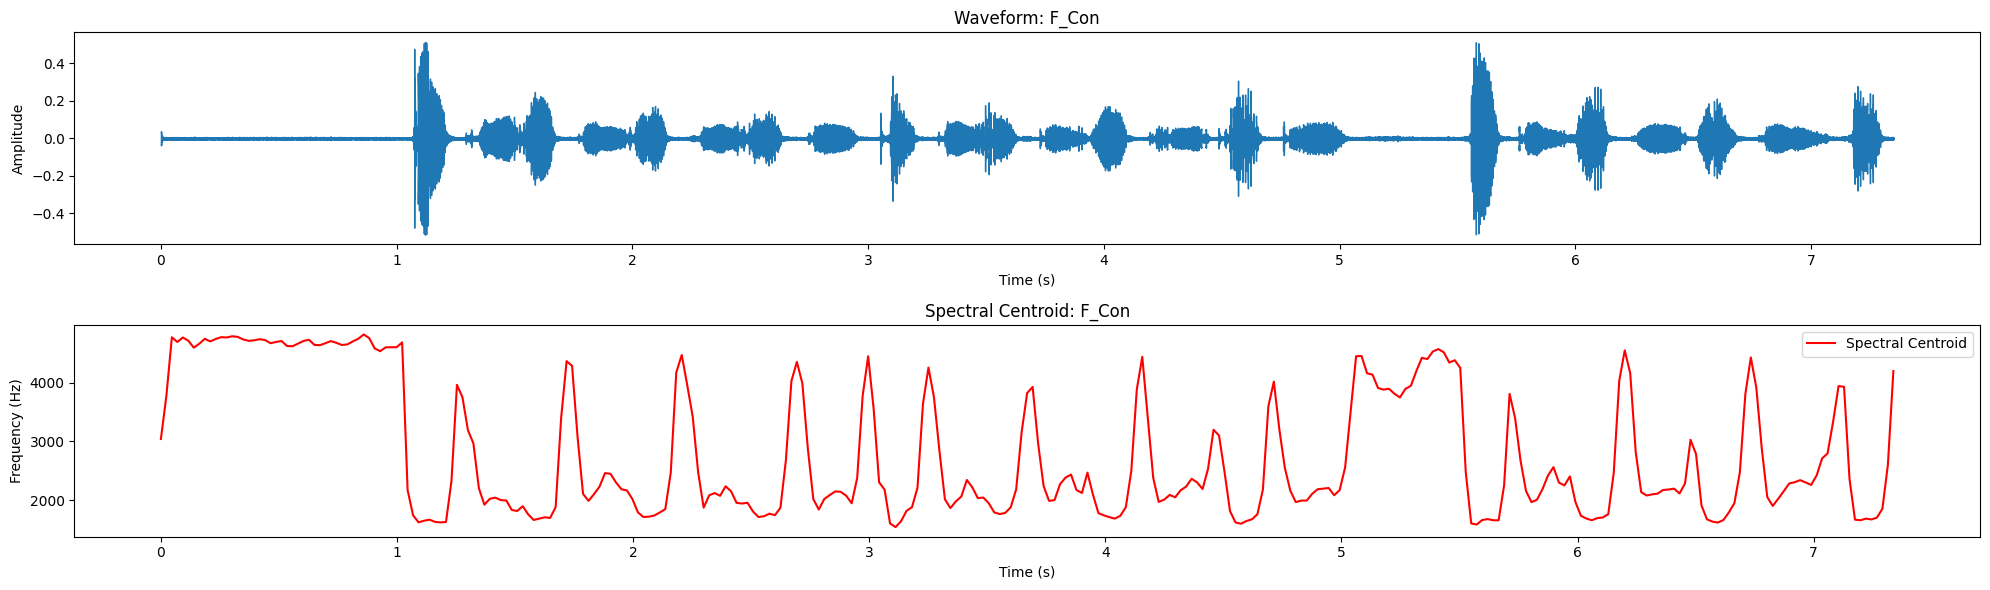

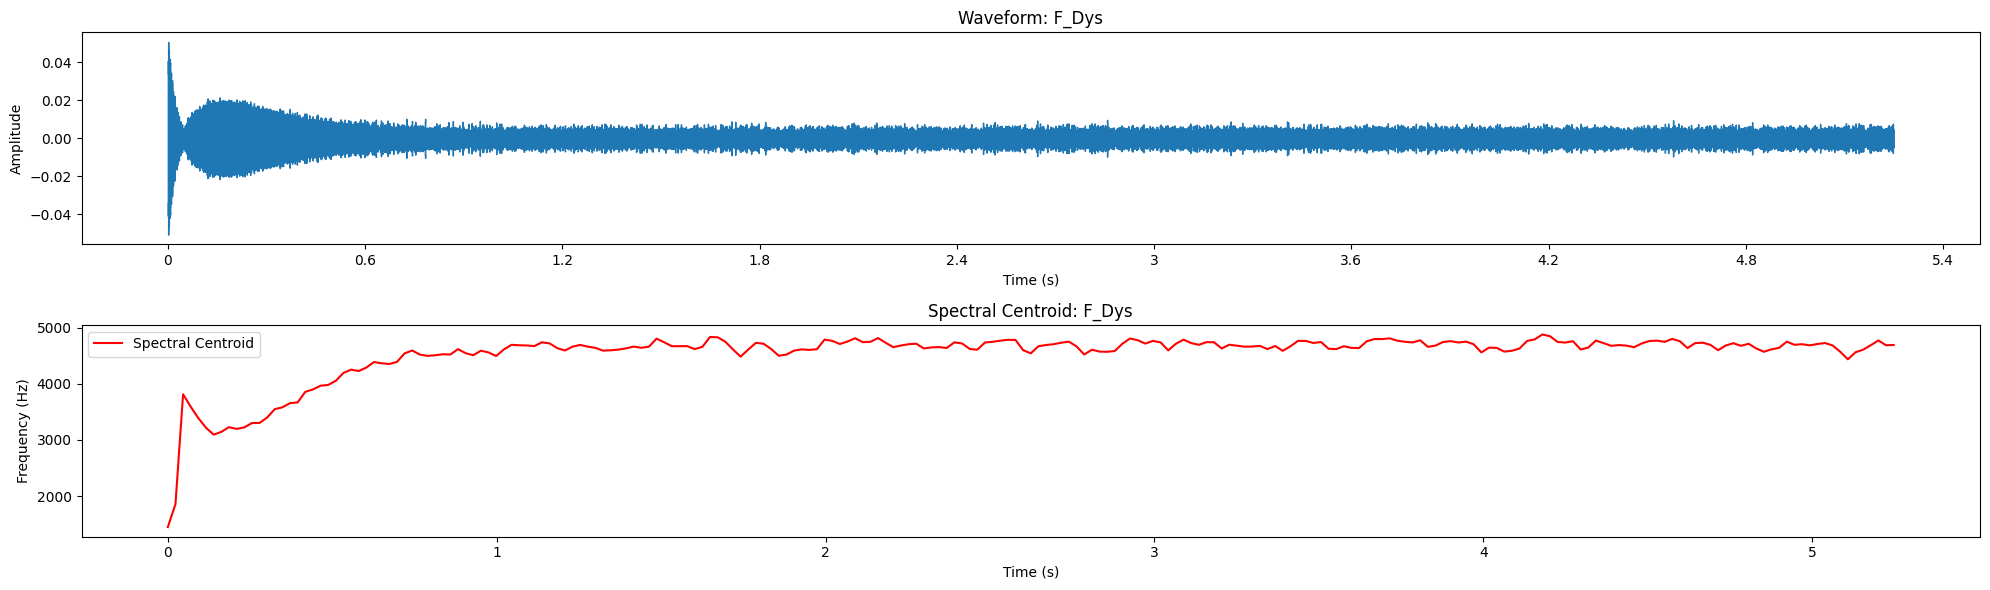

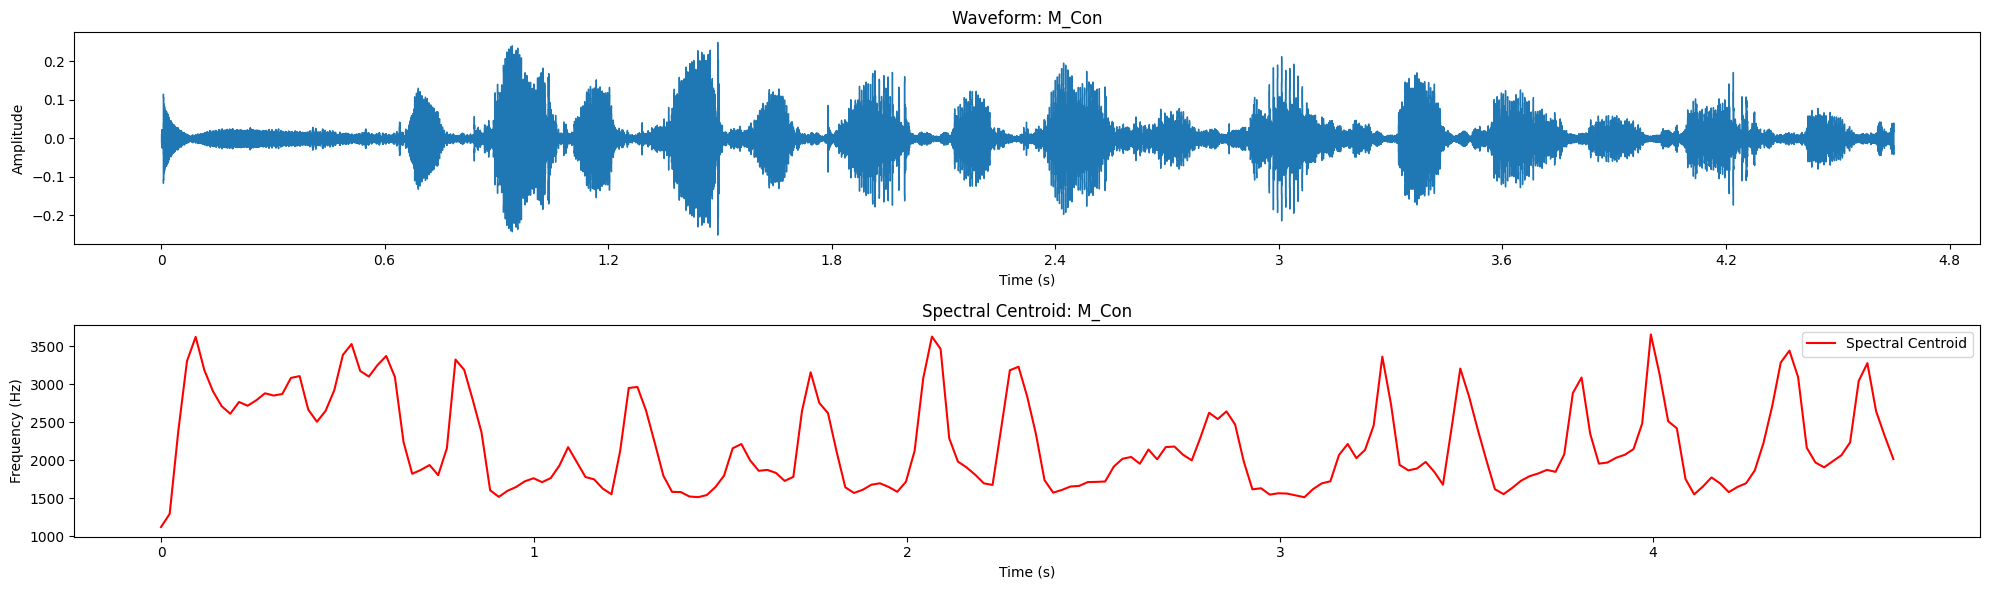

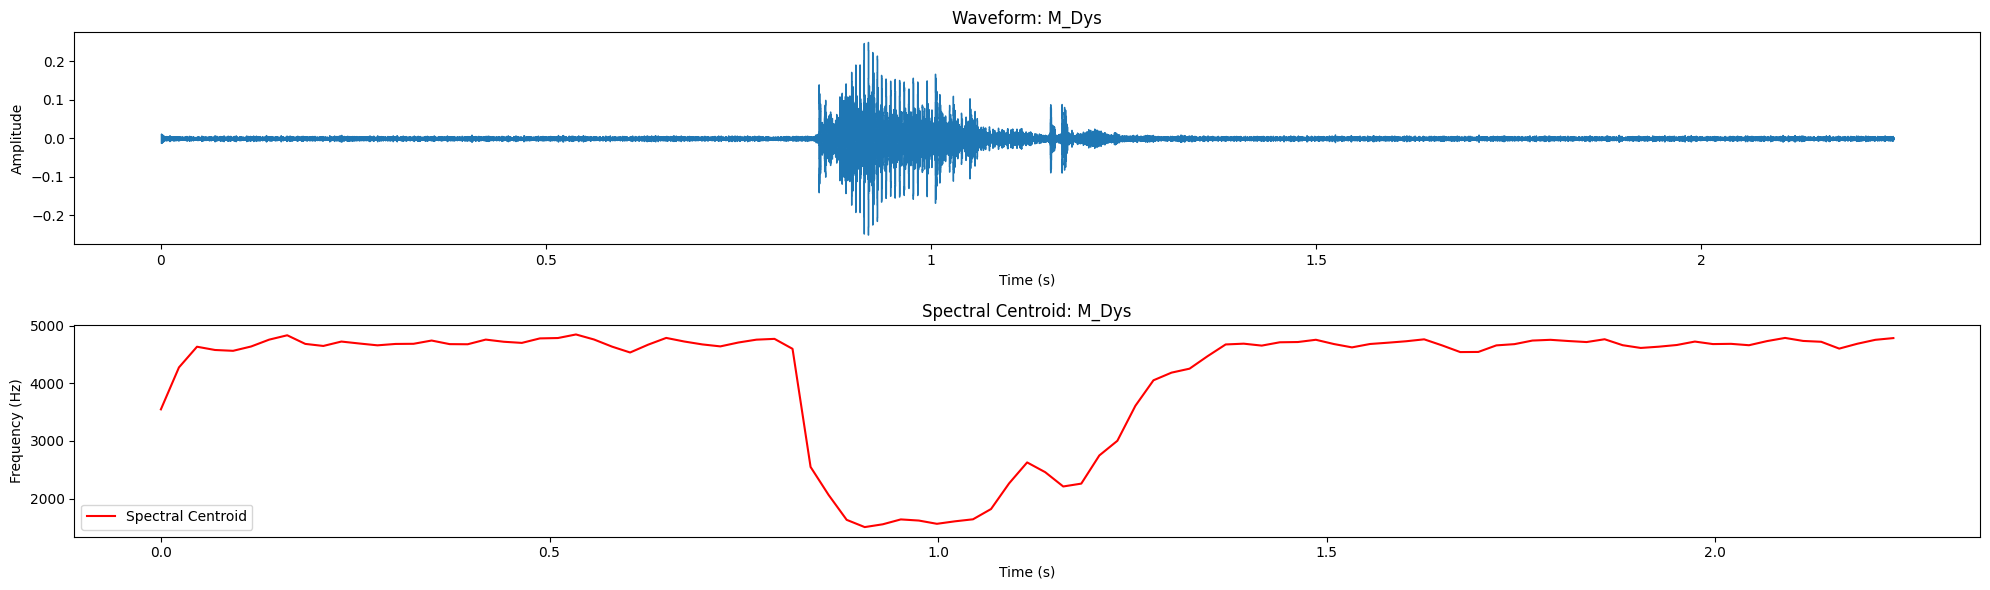

In [9]:
# Function to calculate and plot Spectral Centroid
def show_spectral_centroid(audio_path, label):
    # Load the audio file
    x, sr = librosa.load(audio_path)
    
    # Calculate Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=x, sr=sr)[0]
    
    # Time variable for plotting
    frames = range(len(spectral_centroid))
    t = librosa.frames_to_time(frames, sr=sr)
    
    # Plot waveform and spectral centroid
    plt.figure(figsize=(20, 6))
    
    # Plot waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(x, sr=sr)
    plt.title(f'Waveform: {label}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    # Plot spectral centroid
    plt.subplot(2, 1, 2)
    plt.plot(t, spectral_centroid, color='r', label='Spectral Centroid')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Spectral Centroid: {label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage with your audio files
show_spectral_centroid(F_Con.iloc[1].filename, "F_Con")
show_spectral_centroid(F_Dys.iloc[2].filename, "F_Dys")
show_spectral_centroid(M_Con.iloc[3].filename, "M_Con")
show_spectral_centroid(M_Dys.iloc[4].filename, "M_Dys")

In [10]:
#Fetching audio samples
ipd.Audio(F_Con.iloc[1].filename)

In [ ]:
#Feature Extaction using MFCC
import librosa #for handling music and audio files
import librosa.display #waveforms and spectograms
import IPython.display as ipd #playing audio files in jupyter notebook

#display audio data
for file in os.listdir(r' Training data set'):
  print(file)

data.csv
F_Con
F_Dys
M_Con
M_dys


In [12]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score

In [ ]:
import os
import librosa
import pandas as pd
import numpy as np
from tqdm import tqdm

def feature_extraction(df):
    features = []
    for i, record in tqdm(df.iterrows(), total=df.shape[0]):
        try:
            # Get the full file path
            file_path = record['filename']
            print(f"Processing file: {file_path}")

            # Ensure the file path is correct
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}")
                continue  # Skip to the next file if not found

            # Load the audio file
            x, sr = librosa.load(file_path, sr=None)

            # Extract MFCC features (20 coefficients)
            mfcc = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=128)
            mean_mfcc = np.mean(mfcc, axis=1)
            features.append(mean_mfcc)

        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue  # Continue to the next file if an error occurs

    # Create a DataFrame with the features
    dataf = pd.DataFrame(features)
    if dataf.empty:
        print("No features were extracted.")
    else:
        print("Feature extraction completed.")
    return dataf

# Load CSV file
data = pd.read_csv(r'training data set')

# Ensure file paths are absolute
base_folder = r'training data set'
data['filename'] = data['filename'].apply(lambda x: os.path.join(base_folder, x) if not os.path.isabs(x) else x)

# Call the feature extraction function
dataf = feature_extraction(data)
print(dataf)


  0%|                                                                                 | 4/4515 [00:00<02:00, 37.54it/s]

Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0001.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0002.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0003.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0004.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0005.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0006.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0007.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_ar

  0%|▎                                                                               | 18/4515 [00:00<01:18, 57.17it/s]

Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0012.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0013.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0014.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0015.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0016.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0017.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_arrayMic_FC01S01_0018.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\F_Con\wav_arrayMic_FC01S01\wav_ar

  1%|▌                                                                               | 30/4515 [00:00<01:28, 50.58it/s]

...

Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0255.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0256.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0257.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0258.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0259.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0260.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0261.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0262.wav
Processi

100%|█████████████████████████████████████████████████████████████████████████████▉| 4509/4515 [01:05<00:00, 77.04it/s]

Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0273.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0274.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0275.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0276.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0277.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0278.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_0279.wav
Processing file: C:\Users\Fizza\Documents\Model CNN1\training\data set\M_dys\wav_headMic_M01S02\wav_headMic_M01S02_028.wav
Processin

100%|██████████████████████████████████████████████████████████████████████████████| 4515/4515 [01:05<00:00, 68.90it/s]


Feature extraction completed.
             0          1          2          3          4          5    \
0    -320.633636  31.162016   2.956488   9.534510  12.790991 -16.227764   
1    -300.997284  41.158607  -7.435174   7.761700  17.381989 -22.159197   
2    -420.620941  -9.740300  35.861446  -1.680403  10.240573  -1.752196   
3    -288.113525  60.211166  10.757963  16.713997  21.329540 -10.454901   
4    -385.420135   5.123697  19.085815  -4.672159  13.552992  -6.594711   
...          ...        ...        ...        ...        ...        ...   
4508 -474.847504  61.510956   7.036305  15.509912  12.838791   2.029993   
4509 -538.875793  60.506870   6.602979  17.664738  12.716522   7.141697   
4510 -417.104156  50.428947  -1.166725  34.650860  19.140686  -5.966917   
4511 -466.959045  84.040001   4.526980  14.342254  11.852912  -1.728125   
4512 -478.267700  70.670143  -0.501689  27.040613  22.656801  -2.357682   

           6         7          8          9    ...       118       1

In [ ]:
#checking the column names to be used in next step
import pandas as pd 

# Load your CSV file
dataf = pd.read_csv(r'training data set')  # Replace 'your_file.csv' with the correct path to your file

# Print the column names to verify the presence of 'label'
print(dataf.columns)

Index(['filename', 'label'], dtype='object')


In [24]:
#1)Data Preprocessing 
#1.1) Reshaping the MFCC features 
import numpy as np

# Assuming your MFCC features are stored in a numpy array with shape (4515, 100, 128)
# 4515 samples, 100 frames, and 128 MFCC coefficients per frame
mfcc_features = np.random.rand(4515, 100, 128)  # Replace this with your actual MFCC data

# Reshaping to add channel dimension
mfcc_features = np.expand_dims(mfcc_features, axis=-1)  # Shape: (4515, 100, 128, 1)

print(mfcc_features.shape)  # Should print (4515, 100, 128, 1)

(4515, 100, 128, 1)


In [25]:
#1.2) Normalize the MFCC Features
# Normalize the MFCC features to the range [0, 1]
mfcc_features_normalized = mfcc_features / np.max(np.abs(mfcc_features), axis=(0, 1,2), keepdims=True)

print(mfcc_features_normalized.shape)  # Shape will be the same: (4515, 100, 128, 1)

(4515, 100, 128, 1)


In [26]:
#1.3) Train-Test Split
from sklearn.model_selection import train_test_split

# Example target labels for classification (binary or multi-class)
labels = np.random.randint(0, 2, size=(4515,))  # Example binary labels (adjust for your use case)

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(mfcc_features_normalized, labels, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)  

(3612, 100, 128, 1) (903, 100, 128, 1)


In [27]:
#2) Build the CNN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Assuming:
# - mfcc_features_normalized has shape (num_samples, num_frames, 128, 1)
# - num_classes is the number of classes for classification (adjust based on your task)
# - y_train and y_test are the labels for training and testing

# Define the CNN model
model = Sequential()

# Input layer and first convolutional block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(100, 128, 1)))  # Adjust num_frames and num_coefficients if needed
model.add(MaxPooling2D((2, 2)))

# Second convolutional block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the output of the convolutional layers to feed into fully connected layers
model.add(Flatten())

# Fully connected layers with dropout to prevent overfitting
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer: Adjust num_classes based on your task
# For binary classification, use 'sigmoid'; for multi-class, use 'softmax'
model.add(Dense(1, activation='sigmoid'))  # For binary classification
# model.add(Dense(num_classes, activation='softmax'))  # For multi-class classification

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])  # For binary classification
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])  # For multi-class

# Print the model summary
model.summary()

C:\Users\Fizza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 126, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 44160)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,652,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,671,553 (21.64 MB)

 Trainable params: 5,671,553 (21.64 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.utils import Sequence

class MFCCDataGenerator(Sequence):
    def __init__(self, features, labels, batch_size=32, shuffle=True):
        self.features = features
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.features))
        
    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.features) / self.batch_size))
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        # Generate one batch of data
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_features = self.features[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_features, batch_labels
\
# Initialize the data generators for training and validation
train_generator = MFCCDataGenerator(X_train, y_train, batch_size=32)
validation_generator = MFCCDataGenerator(X_test, y_test, batch_size=32)

# Train the model using the generators
history = model.fit(train_generator, epochs=50, validation_data=validation_generator)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.5111 - loss: 0.6930 - val_accuracy: 0.5045 - val_loss: 0.6931
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.5226 - loss: 0.6935 - val_accuracy: 0.5022 - val_loss: 0.6931
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step - accuracy: 0.5032 - loss: 0.6935 - val_accuracy: 0.5056 - val_loss: 0.6931
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 219ms/step - accuracy: 0.5107 - loss: 0.6932 - val_accuracy: 0.5033 - val_loss: 0.6931
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 237ms/step - accuracy: 0.4844 - loss: 0.6935 - val_accuracy: 0.5045 - val_loss: 0.6931
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 26s 232ms/step - accuracy: 0.5106 - loss: 0.6931 - val_accuracy: 0.5022 - val_loss: 0.6931
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 26s 232ms/step - accuracy: 0.4920 - loss: 0.6936 - val_accuracy: 0.5022 - val_loss: 0.6931
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 215ms/step - accuracy: 0.5098 - loss: 0

In [30]:
#4) Evaluate the Model 
# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5162 - loss: 1.6188
Test Accuracy: 0.5293466448783875


In [ ]:
#5) Save and Load the Model
model_version=1
model.save(r'path\model_v1.keras')

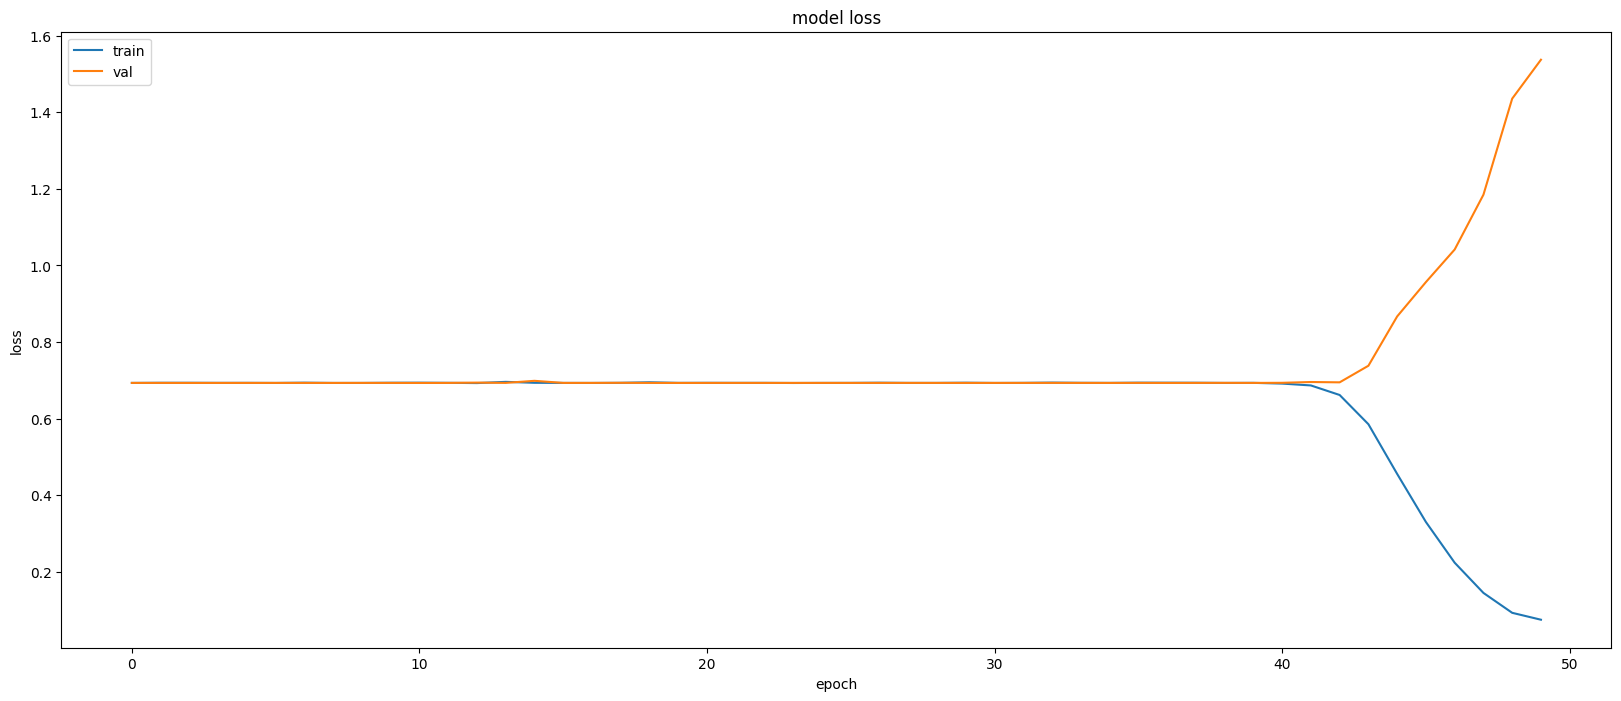

In [32]:
#Learning curves
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

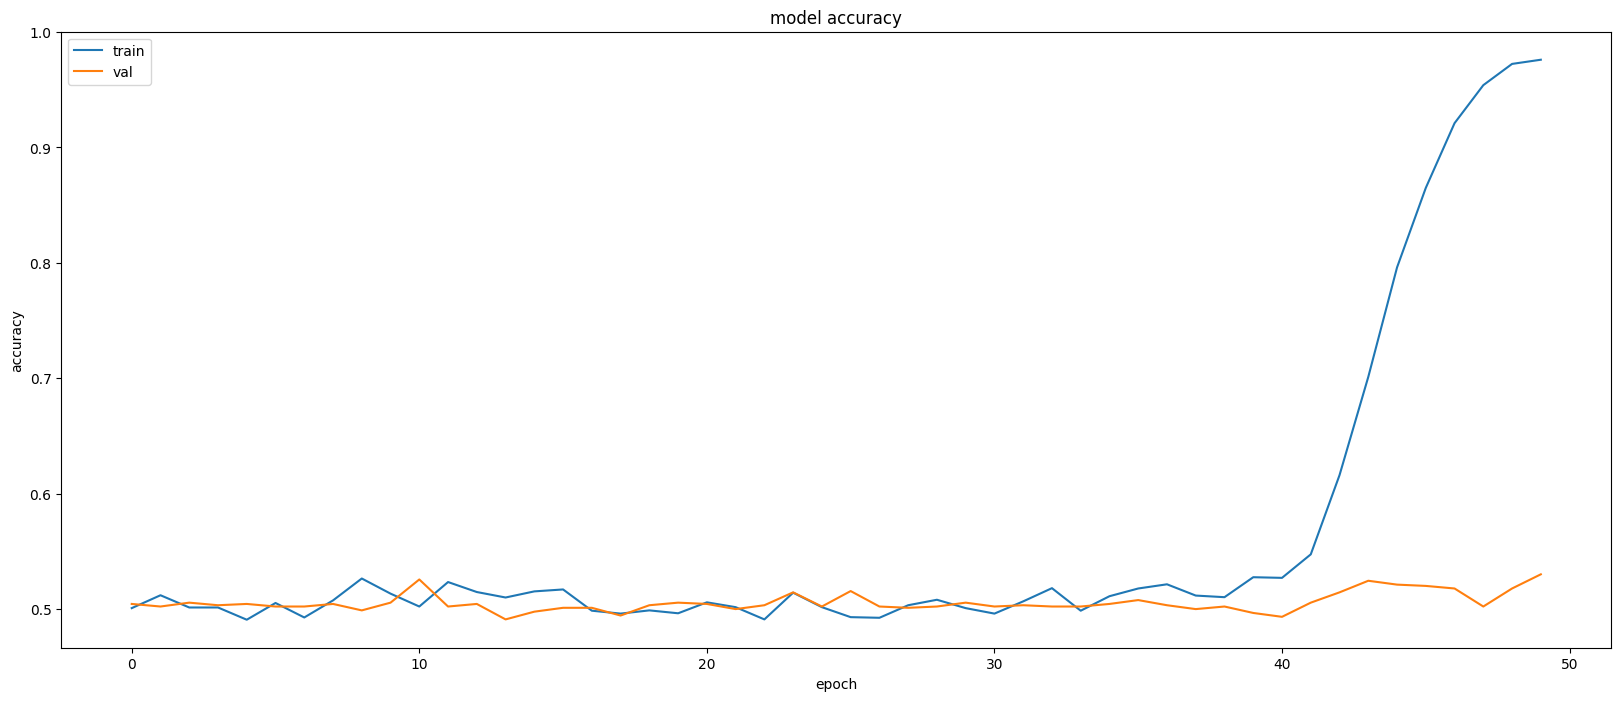

In [33]:
plt.figure(figsize=(20,8))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [34]:
y_pred = model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


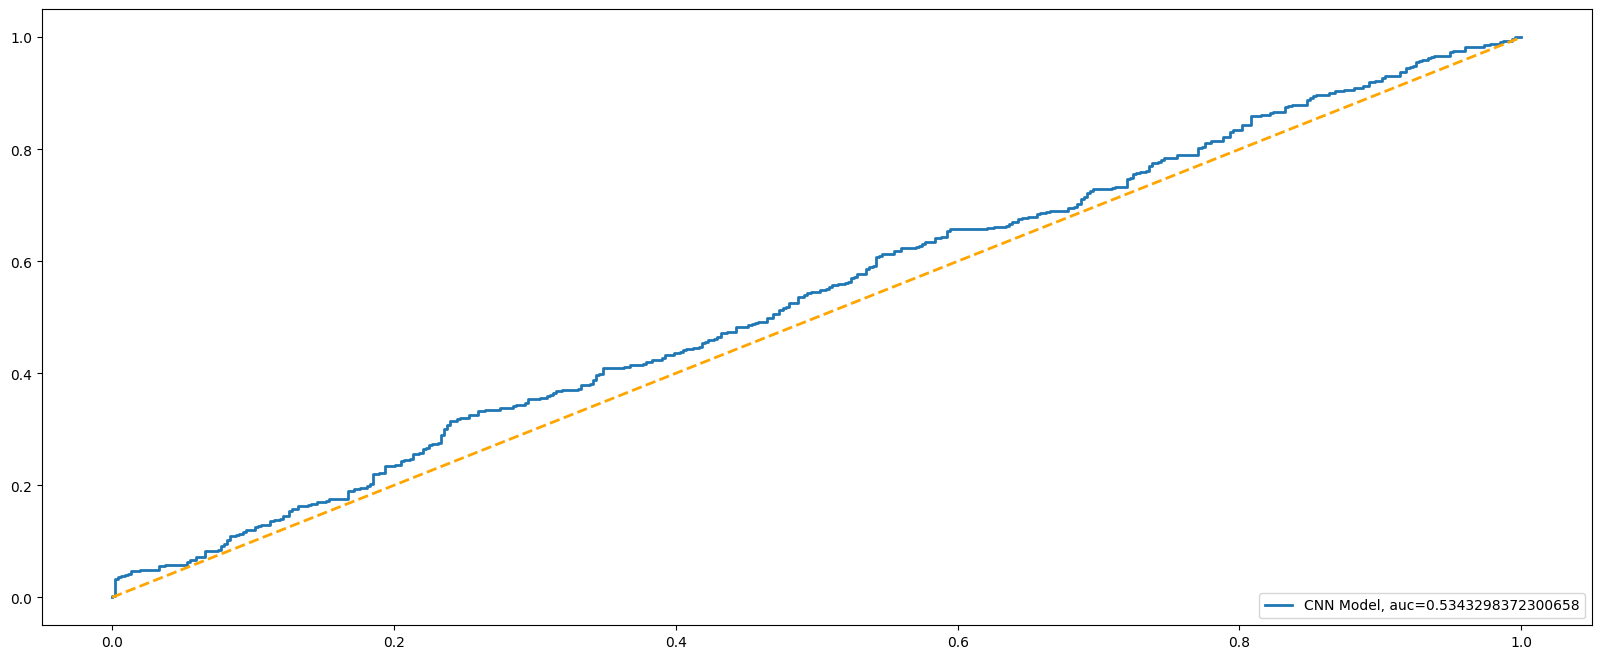

In [35]:
#ROC Curve and AUC Score
plt.figure(figsize=(20,8))
fpr, tpr, _ = roc_curve(y_test,  y_pred)
auc = roc_auc_score(y_test, y_pred)
plt.plot(fpr,tpr,label="CNN Model, auc="+str(auc),lw=2)
plt.plot([0, 1], [0, 1], color="orange", lw=2, linestyle="--")
plt.legend(loc=4)
plt.show()

In [36]:
y_pred[y_pred>=0.5] = 1
y_pred[y_pred<0.5] = 0

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.44      0.49       454
           1       0.52      0.61      0.56       449

    accuracy                           0.53       903
   macro avg       0.53      0.53      0.53       903
weighted avg       0.53      0.53      0.53       903



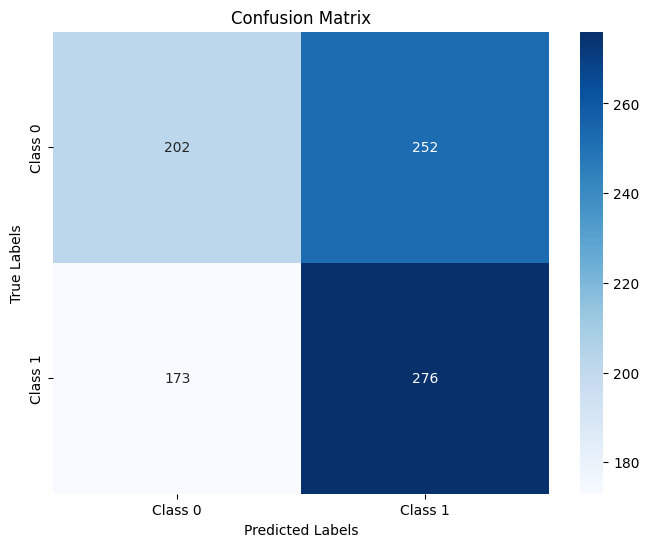

In [37]:
#Cnfusion Matrix and Classification Report
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict the labels for the test set
y_pred = model.predict(X_test)

# Convert probabilities to class labels if it's binary classification
# For binary classification:
y_pred_classes = (y_pred > 0.5).astype("int32")

# For multi-class classification, use:
# y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()